# Modelo Analítico: Flujo 2D Viscoso con Transferencia de Calor y Placa Móvil

## 1. Hipótesis
- Flujo **incompresible** ($\nabla \cdot \mathbf{u} = 0$) y **laminar**.
- Dominio **bidimensional** (variaciones en $x$ y $y$).
- Placa inferior ($y = 0$) se mueve con velocidad $-U_p \hat{i}$ (sentido $-x$).
- Gradiente de presión constante en $x$: $\frac{\partial p}{\partial x} = \text{const.}$
- Efectos gravitacionales despreciables.

## 2. Ecuaciones Gobernantes

### Conservación de Momento (Navier-Stokes 2D)
**Componente $x$**:
$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = -\frac{1}{\rho} \frac{\partial p}{\partial x} + \nu \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)
$$

**Componente $y$**:
$$
\frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} = -\frac{1}{\rho} \frac{\partial p}{\partial y} + \nu \left( \frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2} \right)
$$

donde:
- $u$, $v$: Componentes de velocidad en $x$ e $y$.
- $\nu = \mu/\rho$: Viscosidad cinemática.

### Conservación de Energía
$$
\frac{\partial T}{\partial t} + u \frac{\partial T}{\partial x} + v \frac{\partial T}{\partial y} = \alpha \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right) + \frac{\Phi}{\rho c_p}
$$

**Disipación viscosa ($\Phi$)**:
$$
\Phi = \mu \left[ 2 \left( \frac{\partial u}{\partial x} \right)^2 + 2 \left( \frac{\partial v}{\partial y} \right)^2 + \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)^2 \right]
$$

### Esfuerzo Cortante ($\tau_{xy}$)
$$
\tau_{xy} = \mu \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)
$$

## 3. Condiciones de Frontera

<center>

| **Variable**   | **Placa Inferior ($y=0$)**       | **Superior ($y=H$)**       |
|----------------|----------------------------------|----------------------------|
| Velocidad $u$  | $u = -U_p$                       | $u = U_0$                  |
| Velocidad $v$  | $v = 0$ (no penetración)         | $v = 0$                    |
| Temperatura $T$| $T = T_0$                        | $T = T_1$                  |

</center>

## 4. Simplificaciones para Estado Estacionario
Si $\frac{\partial}{\partial t} = 0$ y $\frac{\partial p}{\partial x} = -\Delta p/L$:
$$
\nu \frac{d^2 u}{dy^2} = \frac{1}{\rho} \frac{\Delta p}{L}, \quad \text{con} \quad u(0) = -U_p, \quad u(H) = U_0
$$

**Solución analítica** para $u(y)$:
$$
u(y) = \frac{\Delta p}{2 \mu L} y (y - H) + \left(U_0 + U_p \frac{y}{H}\right) - U_p
$$


## Adimensionalización


1. Navier-Stokes:
$$
\partial_\tau u_\eta + u_\eta\partial_\eta u_\eta + \Lambda u_\sigma \partial_\sigma u_\eta = - Eu \;\partial_\eta \xi + \varphi (\partial_\eta^2u_\eta + \Lambda^2\partial_\sigma^2u_\eta) 
$$
$$
\partial_\tau u_\sigma + u_\eta\partial_\eta u_\sigma + \Lambda u_\sigma \partial_\sigma u_\sigma = - Eu \;\partial_\sigma \xi + \varphi (\partial_\eta^2u_\sigma + \Lambda^2\partial_\sigma^2u_\sigma)
$$

2. Energía:
$$
\partial_\tau \theta + u_\eta\partial_\eta \theta + \Lambda u_\sigma \partial_\sigma \theta = \beta (\partial_\eta^2 \theta + \Lambda^2 \partial_\sigma^2 \theta) + \delta (2((\partial_\eta u_\eta)^2 + \Lambda^2 (\partial_\sigma u_\sigma)^2) + (\partial_\eta u_\sigma + \Lambda \partial_\sigma u_\eta)^2)
$$

Donde:

<center>

| $\eta = \frac{x}{L}$         | $\sigma = \frac{y}{H}$                  |$\tau = \frac{t}{t_c}$      |
|----------------|----------------------------------|----------------------------|
| $u_\eta = \frac{v_x}{u_0}$  | $u_\sigma = \frac{v_y}{u_0} $     | $\Lambda = \frac{L}{H}$      |
| $\theta = \frac{T - T_0}{T_f - T_0}$       | $\xi = \frac{p - p_0}{p_f - p_0}$ | $Re = \frac{\rho \;u_0 \;L}{\mu}$ |
| $t_c = \frac{L}{u_0}$  |  $\varphi = \frac{\nu}{L\;u_0}$    | $\beta = \frac{\alpha}{u_0 L}$   |
| $Eu = \frac{p_f-p_0}{\rho\;u_0^2}$  | $\delta = \frac{\mu\;u_0}{\rho\;C_p\;L\;(T_f-T_0)}$      |     |

</center>

Con $p_f \approx \frac{\mu (u_0 + u_p) L}{H^2} + p_0$ y $T_f \approx T_0 +\frac{\mu (u_0 +u_p)^2}{k}$

- Condiciones de contorno:

$$
\vec{u}|_{\sigma = 0} = \left( 0, 0\right)
$$
$$
\vec{u}|_{\sigma = 1} = \left( 1, 0\right)
$$
$$
\theta|_{\sigma = 0,1} = 0
$$

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


# =============================================================================
# PARÁMETROS Y CONSTANTES
# =============================================================================
# Propiedades del aire (25°C, 1 atm)
rho = 1.184       # Densidad [kg/m³]
mu = 1.849e-5     # Viscosidad dinámica [Pa·s]
nu = mu/rho       # Viscosidad cinemática [m²/s]
k = 0.0262        # Conductividad térmica [W/(m·K)]
alpha = 2.22e-5   # Difusividad térmica [m²/s]
cp = 1006.0       # Calor específico [J/(kg·K)]

# Escalas características
L = 1.0           # Longitud característica [m]
H = 0.1           # Altura característica [m]
u0 = 2.0          # Velocidad característica [m/s]
up = -1.0         # Velocidad placa [m/s]
T0 = 293.0        # Temperatura referencia [K]
p0 = 101325.0     # Presión referencia [Pa]

# Cálculo de u_c, p_f y T_f
uc = u0 - up      # Velocidad característica corregida
pf = mu*uc*L/H**2 + p0
Tf = T0 + (mu*uc**2)/k

# Parámetros adimensionales

Re = rho*uc*L/mu
Ec = uc**2/(cp * (Tf-T0))
Pr = nu/alpha

# =============================================
# PARÁMETROS ADIMENSIONALES
# =============================================
Lx_star, Ly_star = 2.0, 1.0  # Dimensiones adimensionales
nx, ny = 50, 50               # Puntos en la malla
dx_star = Lx_star/(nx-1)      # Paso espacial x
dy_star = Ly_star/(ny-1)      # Paso espacial y

# Condiciones de frontera
up = -0.5               # Velocidad placa
u0 = 1.0              # Velocidad flujo libre
T0_star = T1_star = 0  # Temperaturas

# Tiempo
dt_star = 0.001               # Paso temporal
nt = 500                      # Pasos totales

# =============================================
# INICIALIZACIÓN
# =============================================
x_star = np.linspace(0, Lx_star, nx)
y_star = np.linspace(0, Ly_star, ny)
X_star, Y_star = np.meshgrid(x_star, y_star)

u_star = np.zeros((ny, nx)) + u0
v_star = np.zeros((ny, nx))
T_star = np.zeros((ny, nx)) + T1_star
p_star = np.zeros((ny, nx))

u_star[0, :] = up
u_star[-1, :] = u0
T_star[0, :] = T0_star
T_star[-1, :] = T1_star

# =============================================
# SIMULACIÓN
# =============================================
u_history, v_history, T_history = [], [], []

for n in range(nt):
    u_old, v_old, T_old = u_star.copy(), v_star.copy(), T_star.copy()

    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Ecuación de momento x
            conv_u = -u_old[i,j]*(u_old[i,j+1]-u_old[i,j-1])/(2*dx_star) \
                     -v_old[i,j]*(u_old[i+1,j]-u_old[i-1,j])/(2*dy_star)
            diff_u = (1/Re)*((u_old[i,j+1]-2*u_old[i,j]+u_old[i,j-1])/dx_star**2 \
                            + (u_old[i+1,j]-2*u_old[i,j]+u_old[i-1,j])/dy_star**2)
            u_star[i,j] = u_old[i,j] + dt_star*(conv_u + diff_u)
            
            # Ecuación de energía
            conv_T = -u_old[i,j]*(T_old[i,j+1]-T_old[i,j-1])/(2*dx_star) \
                     -v_old[i,j]*(T_old[i+1,j]-T_old[i-1,j])/(2*dy_star)
            diff_T = (1/(Re*Pr))*((T_old[i,j+1]-2*T_old[i,j]+T_old[i,j-1])/dx_star**2 \
                                 + (T_old[i+1,j]-2*T_old[i,j]+T_old[i-1,j])/dy_star**2)
            
            # Disipación viscosa
            Sxx = (u_old[i,j+1]-u_old[i,j-1])/(2*dx_star)
            Syy = (v_old[i+1,j]-v_old[i-1,j])/(2*dy_star)
            Sxy = 0.5*((u_old[i+1,j]-u_old[i-1,j])/(2*dy_star) \
                      + (v_old[i,j+1]-v_old[i,j-1])/(2*dx_star))
            viscous_heating = (Ec/Re)*(2*(Sxx**2 + Syy**2) + 4*Sxy**2)
            
            T_star[i,j] = T_old[i,j] + dt_star*(conv_T + diff_T + viscous_heating)

    # Condiciones de frontera
    v_star[:, 0], v_star[:, -1] = v_star[:, -2], v_star[:, 1]
    u_star[0, :], u_star[-1, :] = up, u0
    v_star[0, :], v_star[-1, :] = 0, 0
    T_star[0, :], T_star[-1, :] = T0_star, T1_star
    
    if n % 10 == 0:
        u_history.append(u_star.copy())
        v_history.append(v_star.copy())
        T_history.append(T_star.copy())

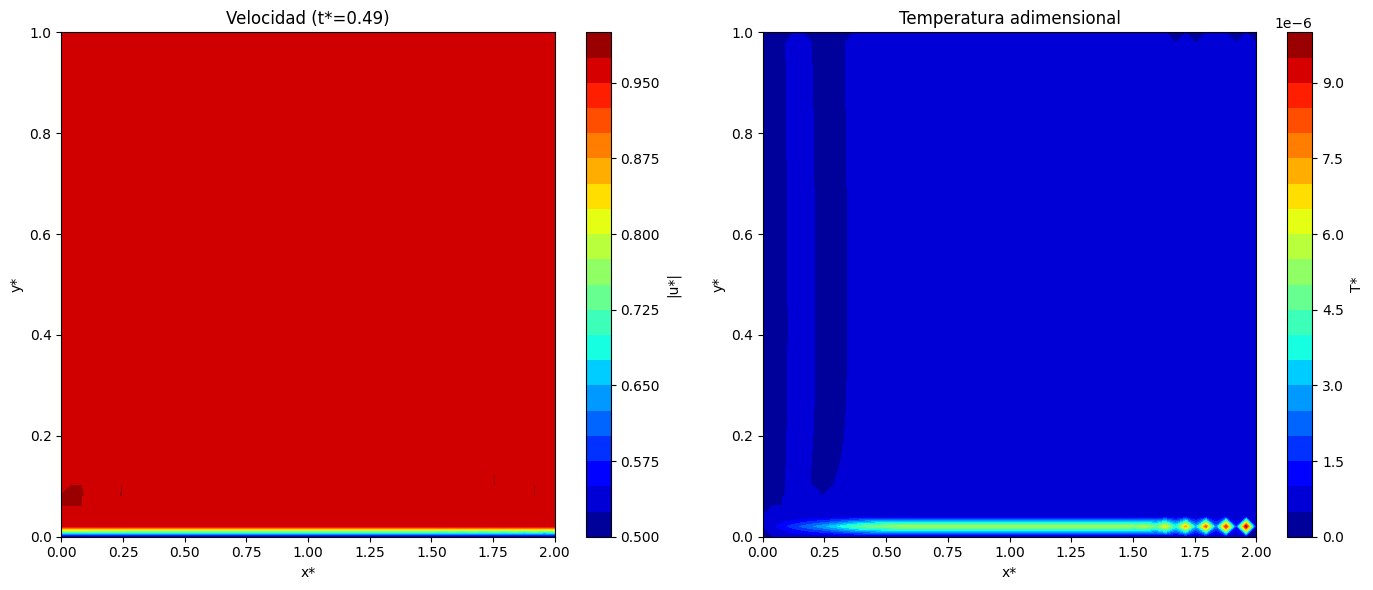

In [28]:
# =============================================
# VISUALIZACIÓN DE RESULTADOS FINALES
# =============================================


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Configuración inicial
speed = np.sqrt(u_history[0]**2 + v_history[0]**2)
cont1 = ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
cbar1 = fig.colorbar(cont1, ax=ax1)
cbar1.set_label('|u*|')
# stream = ax1.streamplot(X_star, Y_star, u_history[0], v_history[0], color='k', density=1.5)
title1 = ax1.set_title(f'Velocidad (t*=0.00)')
ax1.set_xlabel('x*')
ax1.set_ylabel('y*')

cont2 = ax2.contourf(X_star, Y_star, T_history[0], levels=20, cmap='jet')
cbar2 = fig.colorbar(cont2, ax=ax2)
cbar2.set_label('T*')
title2 = ax2.set_title('Temperatura adimensional')
ax2.set_xlabel('x*')
ax2.set_ylabel('y*')

plt.tight_layout()

def init():
    return []

def update(frame):
    # Actualizar datos
    speed = np.sqrt(u_history[frame]**2 + v_history[frame]**2)
    
    # Actualizar contornos
    for coll in ax1.collections:
        coll.remove()
    cont1 = ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
    
    '''    # Actualizar streamplot
    for line in ax1.lines:
        line.remove()
    stream = ax1.streamplot(X_star, Y_star, u_history[frame], v_history[frame], color='k', density=1.5)
    '''
    # Actualizar temperatura
    for coll in ax2.collections:
        coll.remove()
    cont2 = ax2.contourf(X_star, Y_star, T_history[frame], levels=20, cmap='jet')
    
    # Actualizar títulos
    title1.set_text(f'Velocidad (t*={frame*10*dt_star:.2f})')
    
    # Retornar todos los artistas actualizados
    return [cont1, stream.lines, cont2, title1] + ax1.collections + ax2.collections

anim = FuncAnimation(fig, update, frames=len(u_history), init_func=init, interval=100, blit=True)
HTML(anim.to_jshtml())

Altura de la capa límite (y*): 0.0204


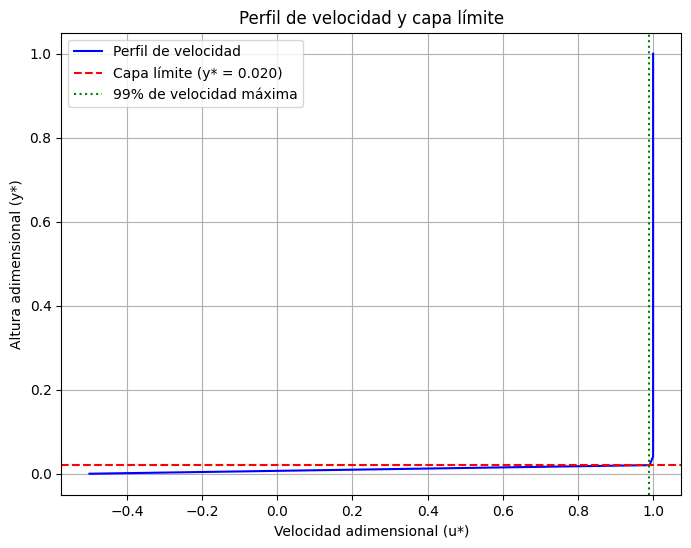

In [ ]:
# Seleccionar una posición en x (por ejemplo, el centro del dominio)
x_idx = nx // 2  
u_profile = u_star[:, x_idx]  # Perfil de velocidad en esa posición

# Valor máximo de velocidad (u0 en este caso)
u_max = u0

# Encontrar el índice donde la velocidad alcanza el 99% del máximo
threshold = 0.99 * u_max
boundary_layer_idx = np.where(u_profile >= threshold)[0][0]

# Obtener la altura adimensional correspondiente
y_boundary_layer = y_star[boundary_layer_idx]

print(f"Altura de la capa límite (y*): {y_boundary_layer:.4f}")

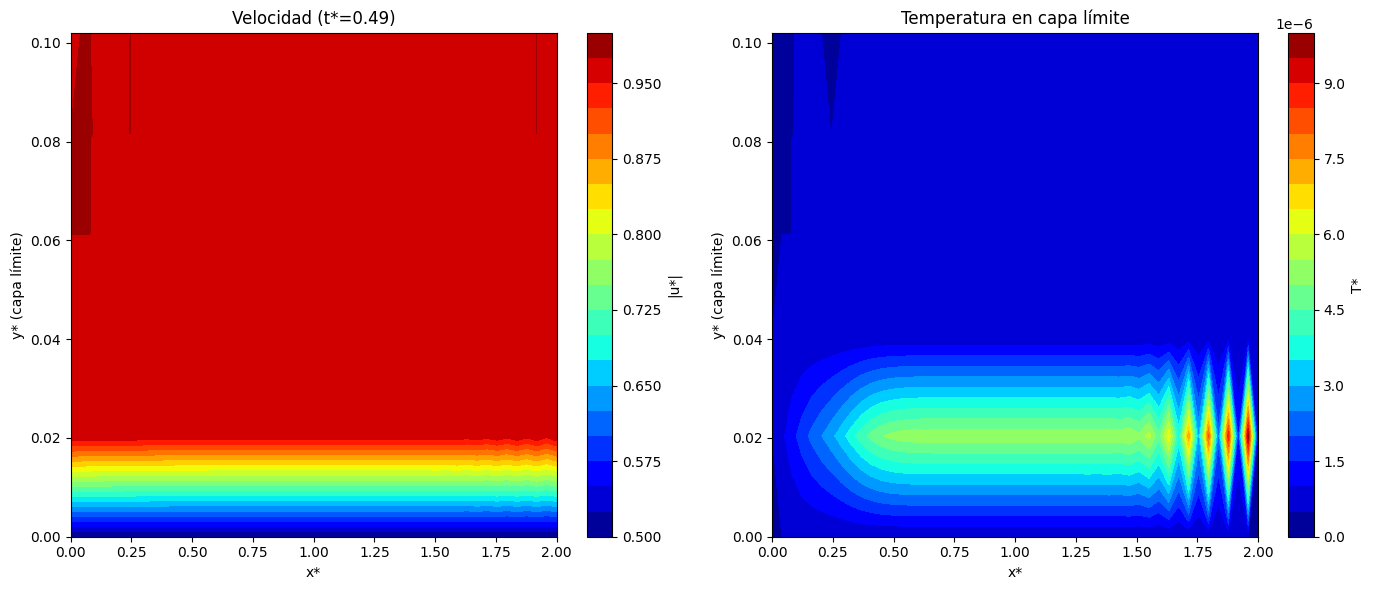

In [34]:
# =============================================
# VISUALIZACIÓN DE LA CAPA LÍMITE (TRUNCADA)
# =============================================

# 1. Calcular boundary_layer_idx para el primer frame (asumiendo que no cambia mucho)
u_profile = u_history[0][:, nx//2]  # Perfil en x* central
boundary_layer_idx = np.where(y_star <= 5 * y_boundary_layer)[0]

# 2. Truncar las coordenadas y datos históricos
X_star_bl = X_star[boundary_layer_idx, :]
Y_star_bl = Y_star[boundary_layer_idx, :]

u_history_bl = [u[boundary_layer_idx, :] for u in u_history]
v_history_bl = [v[boundary_layer_idx, :] for v in v_history]
T_history_bl = [T[boundary_layer_idx, :] for T in T_history]

# 3. Configurar la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Configuración inicial (usando datos truncados)
speed = np.sqrt(u_history_bl[0]**2 + v_history_bl[0]**2)
cont1 = ax1.contourf(X_star_bl, Y_star_bl, speed, levels=20, cmap='jet')
cbar1 = fig.colorbar(cont1, ax=ax1)
cbar1.set_label('|u*|')
title1 = ax1.set_title(f'Velocidad (t*=0.00)')
ax1.set_xlabel('x*')
ax1.set_ylabel('y* (capa límite)')
ax1.set_ylim(0, 5 * y_boundary_layer)  # Asegurar que el eje y no muestre valores fuera de la capa

cont2 = ax2.contourf(X_star_bl, Y_star_bl, T_history_bl[0], levels=20, cmap='jet')
cbar2 = fig.colorbar(cont2, ax=ax2)
cbar2.set_label('T*')
title2 = ax2.set_title('Temperatura en capa límite')
ax2.set_xlabel('x*')
ax2.set_ylabel('y* (capa límite)')
ax2.set_ylim(0, 5 * y_boundary_layer)

plt.tight_layout()

def init():
    return []

def update(frame):
    # Actualizar datos (usando versiones truncadas)
    speed = np.sqrt(u_history_bl[frame]**2 + v_history_bl[frame]**2)
    
    # Limpiar y recrear contornos
    ax1.clear()
    cont1 = ax1.contourf(X_star_bl, Y_star_bl, speed, levels=20, cmap='jet')
    ax1.set_title(f'Velocidad (t*={frame*10*dt_star:.2f})')
    ax1.set_xlabel('x*')
    ax1.set_ylabel('y* (capa límite)')
    ax1.set_ylim(0, 5 * y_boundary_layer)
    
    ax2.clear()
    cont2 = ax2.contourf(X_star_bl, Y_star_bl, T_history_bl[frame], levels=20, cmap='jet')
    ax2.set_title('Temperatura en capa límite')
    ax2.set_xlabel('x*')
    ax2.set_ylabel('y* (capa límite)')
    ax2.set_ylim(0, 5 * y_boundary_layer)
    
    return [cont1, cont2]

anim = FuncAnimation(fig, update, frames=len(u_history_bl), init_func=init, interval=100, blit=False)
HTML(anim.to_jshtml())

## Bonito

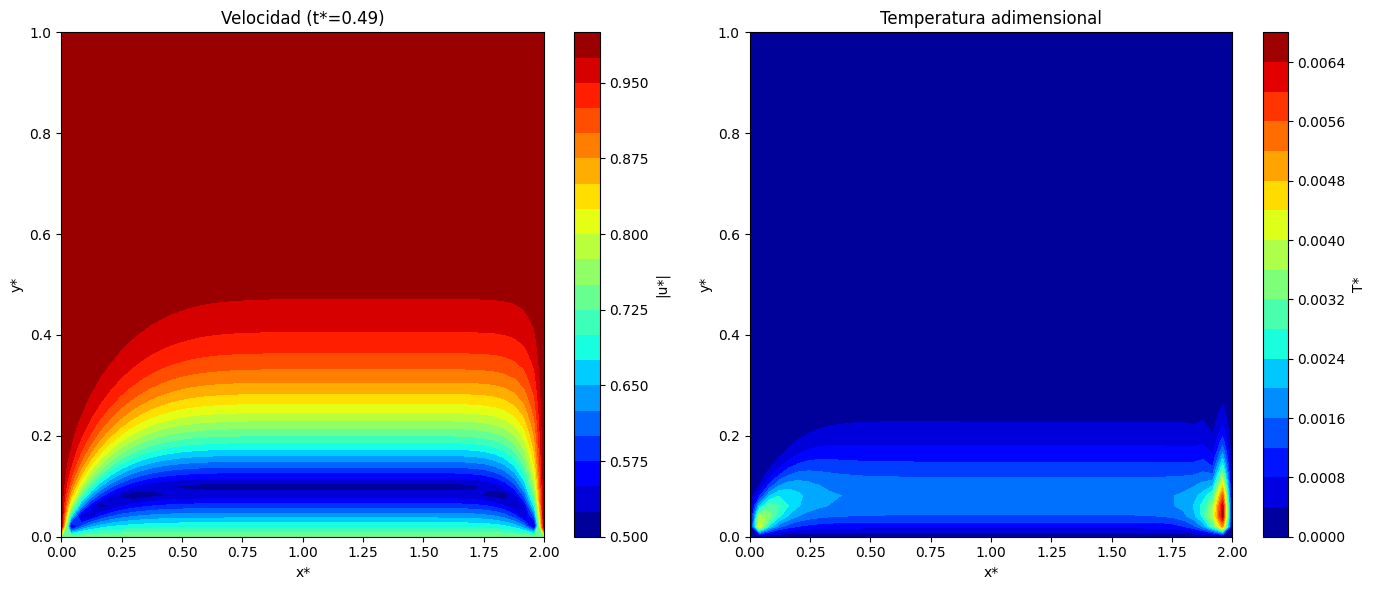

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


# =============================================================================
# PARÁMETROS Y CONSTANTES
# =============================================================================
# Propiedades del aire (25°C, 1 atm)
rho = 1.184       # Densidad [kg/m³]
mu = 1.849e-5     # Viscosidad dinámica [Pa·s]
nu = mu/rho       # Viscosidad cinemática [m²/s]
k = 0.0262        # Conductividad térmica [W/(m·K)]
alpha = 2.22e-5   # Difusividad térmica [m²/s]
cp = 1006.0       # Calor específico [J/(kg·K)]

# Escalas características
L = 1.0           # Longitud característica [m]
H = 0.1           # Altura característica [m]
u0 = 2.0          # Velocidad característica [m/s]
up = -1.0         # Velocidad placa [m/s]
T0 = 293.0        # Temperatura referencia [K]
p0 = 101325.0     # Presión referencia [Pa]

# Cálculo de u_c, p_f y T_f
uc = u0 - up      # Velocidad característica corregida
pf = mu*uc*L/H**2 + p0
Tf = T0 + (mu*uc**2)/k

# Parámetros adimensionales
'''
Re = rho*uc*L/mu
Ec = uc**2/(cp * (Tf-T0))
Pr = nu/alpha'''

Re = 20.0                     # Reynolds
Pr = 10.0                     # Prandtl
Ec = 0.1                      # Eckert

# =============================================
# PARÁMETROS ADIMENSIONALES
# =============================================
Lx_star, Ly_star = 2.0, 1.0  # Dimensiones adimensionales
nx, ny = 50, 50               # Puntos en la malla
dx_star = Lx_star/(nx-1)      # Paso espacial x
dy_star = Ly_star/(ny-1)      # Paso espacial y

# Condiciones de frontera
up = -0.5               # Velocidad placa
u0 = 1.0              # Velocidad flujo libre
T0_star = T1_star = 0  # Temperaturas

# Tiempo
dt_star = 0.001               # Paso temporal
nt = 500                      # Pasos totales

# =============================================
# INICIALIZACIÓN
# =============================================
x_star = np.linspace(0, Lx_star, nx)
y_star = np.linspace(0, Ly_star, ny)
X_star, Y_star = np.meshgrid(x_star, y_star)

u_star = np.zeros((ny, nx)) + u0
v_star = np.zeros((ny, nx))
T_star = np.zeros((ny, nx)) + T1_star
p_star = np.zeros((ny, nx))

u_star[0, :] = up
u_star[-1, :] = u0
T_star[0, :] = T0_star
T_star[-1, :] = T1_star

# =============================================
# SIMULACIÓN
# =============================================
u_history, v_history, T_history = [], [], []

for n in range(nt):
    u_old, v_old, T_old = u_star.copy(), v_star.copy(), T_star.copy()

    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Ecuación de momento x
            conv_u = -u_old[i,j]*(u_old[i,j+1]-u_old[i,j-1])/(2*dx_star) \
                     -v_old[i,j]*(u_old[i+1,j]-u_old[i-1,j])/(2*dy_star)
            diff_u = (1/Re)*((u_old[i,j+1]-2*u_old[i,j]+u_old[i,j-1])/dx_star**2 \
                            + (u_old[i+1,j]-2*u_old[i,j]+u_old[i-1,j])/dy_star**2)
            u_star[i,j] = u_old[i,j] + dt_star*(conv_u + diff_u)
            
            # Ecuación de energía
            conv_T = -u_old[i,j]*(T_old[i,j+1]-T_old[i,j-1])/(2*dx_star) \
                     -v_old[i,j]*(T_old[i+1,j]-T_old[i-1,j])/(2*dy_star)
            diff_T = (1/(Re*Pr))*((T_old[i,j+1]-2*T_old[i,j]+T_old[i,j-1])/dx_star**2 \
                                 + (T_old[i+1,j]-2*T_old[i,j]+T_old[i-1,j])/dy_star**2)
            
            # Disipación viscosa
            Sxx = (u_old[i,j+1]-u_old[i,j-1])/(2*dx_star)
            Syy = (v_old[i+1,j]-v_old[i-1,j])/(2*dy_star)
            Sxy = 0.5*((u_old[i+1,j]-u_old[i-1,j])/(2*dy_star) \
                      + (v_old[i,j+1]-v_old[i,j-1])/(2*dx_star))
            viscous_heating = (Ec/Re)*(2*(Sxx**2 + Syy**2) + 4*Sxy**2)
            
            T_star[i,j] = T_old[i,j] + dt_star*(conv_T + diff_T + viscous_heating)

    # Condiciones de frontera
    v_star[:, 0], v_star[:, -1] = v_star[:, -2], v_star[:, 1]
    u_star[0, :], u_star[-1, :] = up, u0
    v_star[0, :], v_star[-1, :] = 0, 0
    T_star[0, :], T_star[-1, :] = T0_star, T1_star
    
    if n % 10 == 0:
        u_history.append(u_star.copy())
        v_history.append(v_star.copy())
        T_history.append(T_star.copy())

# =============================================
# VISUALIZACIÓN DE RESULTADOS FINALES
# =============================================


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Configuración inicial
speed = np.sqrt(u_history[0]**2 + v_history[0]**2)
cont1 = ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
cbar1 = fig.colorbar(cont1, ax=ax1)
cbar1.set_label('|u*|')
# stream = ax1.streamplot(X_star, Y_star, u_history[0], v_history[0], color='k', density=1.5)
title1 = ax1.set_title(f'Velocidad (t*=0.00)')
ax1.set_xlabel('x*')
ax1.set_ylabel('y*')

cont2 = ax2.contourf(X_star, Y_star, T_history[0], levels=20, cmap='jet')
cbar2 = fig.colorbar(cont2, ax=ax2)
cbar2.set_label('T*')
title2 = ax2.set_title('Temperatura adimensional')
ax2.set_xlabel('x*')
ax2.set_ylabel('y*')

plt.tight_layout()

def init():
    return []

def update(frame):
    # Actualizar datos
    speed = np.sqrt(u_history[frame]**2 + v_history[frame]**2)
    
    # Actualizar contornos
    for coll in ax1.collections:
        coll.remove()
    cont1 = ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
    
    '''    # Actualizar streamplot
    for line in ax1.lines:
        line.remove()
    stream = ax1.streamplot(X_star, Y_star, u_history[frame], v_history[frame], color='k', density=1.5)
    '''
    # Actualizar temperatura
    for coll in ax2.collections:
        coll.remove()
    cont2 = ax2.contourf(X_star, Y_star, T_history[frame], levels=20, cmap='jet')
    
    # Actualizar títulos
    title1.set_text(f'Velocidad (t*={frame*10*dt_star:.2f})')
    
    # Retornar todos los artistas actualizados
    return [cont1, stream.lines, cont2, title1] + ax1.collections + ax2.collections

anim = FuncAnimation(fig, update, frames=len(u_history), init_func=init, interval=100, blit=True)
HTML(anim.to_jshtml())